# 2 · Ensembles: seed-ensemble, AE/DAE y heterogéneo

El problema #1 diagnosticado del VAE era la **varianza entre semillas** (cada
seed converge distinto). Solución: **seed-ensemble** — promediar los scores
normalizados (z-score per-miembro) de 10 VAEs con semillas distintas. El
`EnsembleDetector` es agnóstico al modelo, así que la misma idea aplica a AE/DAE y a
ensembles heterogéneos.

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## El seed-ensemble resuelve la varianza (soja)

In [2]:
explib.show(explib.tbl_ensembles())

,modelo,soja_pr,soja_std,nota
0,VAE single (vae_v4),0.559,0.035,1 modelo: alta varianza
1,VAE seed-ensemble ×10,0.592,0.010,"promedia 10 seeds: var ÷3, media ↑"
2,Hetero VAE+IForest,0.427,0.025,el IForest más débil arrastra
3,AE seed-ensemble ×10,0.339,0.003,ensemble no salva base débil


- **VAE single → seed-ensemble**: la varianza cae (±0.035 → ±0.010) **y la
  media sube** (0.559 → 0.592). El promedio cancela los errores idiosincráticos de
  cada semilla y conserva la señal compartida.
- **Hetero VAE+IForest**: mixto — el IForest, más débil, arrastra la soja hacia abajo.
- **AE/DAE ensembles**: bajan la varianza pero no salvan un base débil (MSE).

### Curvas PR: single vs ensemble

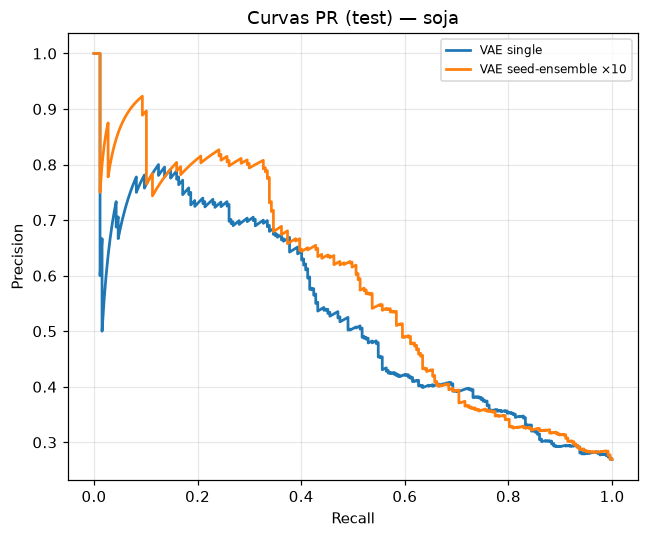

In [3]:
explib.plot_pr_curves([("vae_v4_reconprob_lat16","VAE single"),
                       ("vae_seedens_v1","VAE seed-ensemble ×10")], "soja"); plt.show()

### PR-AUC con desvío estándar: el ensemble baja la varianza
Comparación directa (barras con ±std) — se ve cómo el ensemble achica el desvío.

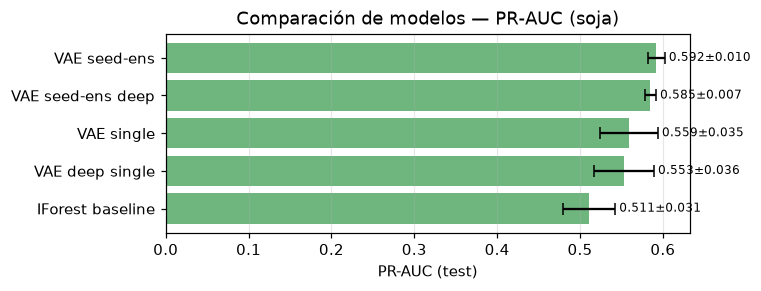

In [4]:
explib.plot_metric_comparison([
    ("iforest_v2_mf03_n200","IForest baseline"),
    ("vae_v4_reconprob_lat16","VAE single"),
    ("vae_v15_reconprob_deep","VAE deep single"),
    ("vae_seedens_v1","VAE seed-ens"),
    ("vae_seedens_deep","VAE seed-ens deep"),
], "soja", metric="pr_auc"); plt.show()

Mismo con **Recall@contam** (cuántas anomalías reales capturamos al presupuesto del 10%):

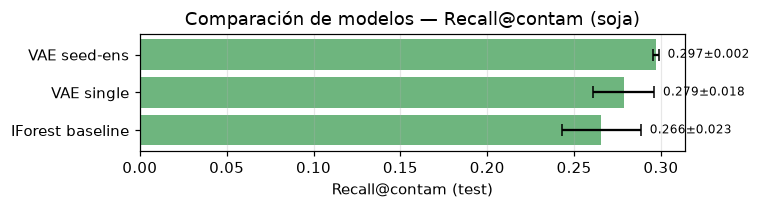

In [5]:
explib.plot_metric_comparison([
    ("iforest_v2_mf03_n200","IForest baseline"),
    ("vae_v4_reconprob_lat16","VAE single"),
    ("vae_seedens_v1","VAE seed-ens"),
], "soja", metric="recall_at_contamination"); plt.show()

**Conclusión:** el seed-ensemble del VAE `recon_prob` es el modelo final (SOTA).